In [37]:
import pandas as pd
all_experiment_rows = []

## RUN 1
N = 50        
K = 2         
B = 3000       

SIGMA_U = 1.0
TAU = 0.02
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0]


Running MCMC Chains Sequentially to Bypass OS Traps...

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [00:05, 105.96it/s, step size=4.21e-01, acc. prob=0.880]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [00:06, 95.14it/s, step size=4.27e-01, acc. prob=0.864] 


  └── Mean Bulk ESS : 1682.55
  └── Max R-hat     : 1.0200
  └── Divergences   : 0

Running Lambda = 1.0...
  └── Sampling Chain 1/2...


...

  └── Mean Bulk ESS : 1218.46
  └── Max R-hat     : 1.0200
  └── Divergences   : 0

Running Lambda = 100.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [02:02,  4.90it/s, step size=8.25e-02, acc. prob=0.855]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [01:50,  5.45it/s, step size=9.63e-02, acc. prob=0.822]


  └── Mean Bulk ESS : 916.79
  └── Max R-hat     : 1.0300
  └── Divergences   : 0

Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 1682.5          | 1.0200       | 0         
1.0        | 1227.8          | 1.0100       | 0         
10.0       | 907.9           | 1.0200       | 0         
25.0       | 1218.5          | 1.0200       | 0         
100.0      | 916.8           | 1.0300       | 0         


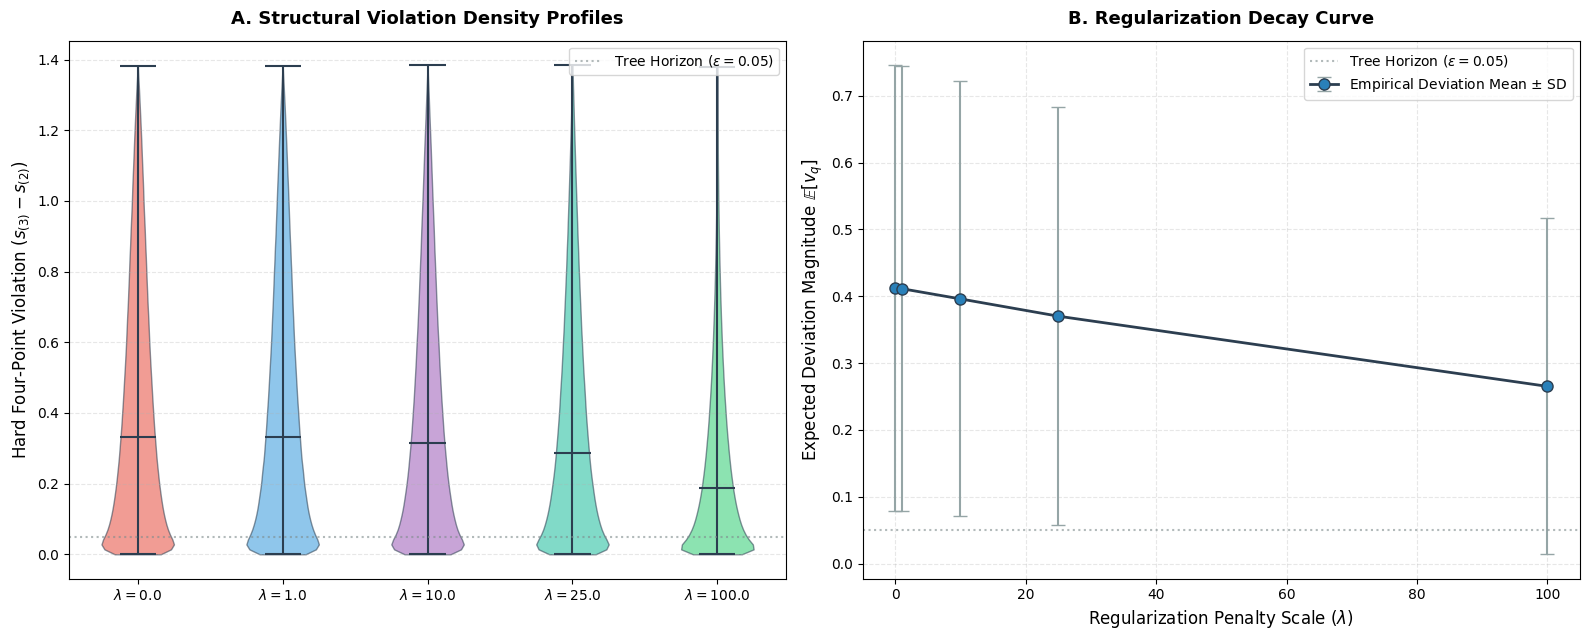

In [35]:
import sys
sys.path.append(".")  # Path fix for local 'src' imports

import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

from src.model import PhylogeneticPrior

# --- Global Configurations ---
N = 50        
K = 2         
B = 3000       

SIGMA_U = 1.0
TAU = 0.02
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0]

# Instantiate your project model globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    experiment_reports = {}

    print("Running MCMC Chains Sequentially to Bypass OS Traps...")

    for lmbda in LAMBDA_GRID:
        print(f"\nRunning Lambda = {lmbda}...")
        
        # Lists to store the trace data from our separate chains
        chain_samples = []
        chain_diagnostics = []
        
        # Run 2 chains one after the other completely inside the main process thread
        for chain_id in range(2):
            print(f"  └── Sampling Chain {chain_id + 1}/2...")
            pyro.clear_param_store()
            
            # Set a unique seed per chain so they sample from different starting points
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            # Clean default NUTS initialization running a single chain safely
            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=400, 
                warmup_steps=200, 
                num_chains=1  # Avoids triggering any background process engines
            )
            mcmc.run()
            
            # Extract current chain data
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # --- Merge Chain Data for ArviZ ---
        # Combine the unconstrained variables 'u' across a new chain axis
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0) # Shape: (chains, samples, N, K)
        posterior_dict = {"u": combined_u}
        
        # Re-materialize the distance matrices 'D' for our violin plot using the pooled trace
        pooled_samples = {"u": combined_u.view(-1, N, K)} # Flatten chain axis for Predictive
        def target_model_pooled():
            return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)
            
        predictive = infer.Predictive(target_model_pooled, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Calculate total combined divergences across both chains
        total_divergences = 0
        for diag in chain_diagnostics:
            total_divergences += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Convert the multi-chain dictionary data structure directly into ArviZ
        az_data = az.from_dict(posterior=posterior_dict)
        summary_stats = az.summary(az_data)
        
        mean_ess = summary_stats["ess_bulk"].mean()
        max_rhat = summary_stats["r_hat"].max()
        
        experiment_reports[lmbda] = {
            "mean_ess": mean_ess,
            "max_rhat": max_rhat,
            "divergences": total_divergences
        }
        
        print(f"  └── Mean Bulk ESS : {mean_ess:.2f}")
        print(f"  └── Max R-hat     : {max_rhat:.4f}")
        print(f"  └── Divergences   : {total_divergences}")

    # --- Focused Summary Report ---
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda, metrics in experiment_reports.items():
        print(f"{lmbda:<10} | {metrics['mean_ess']:<15.1f} | {metrics['max_rhat']:<12.4f} | {metrics['divergences']:<10}")
    print("="*55)

    # --- Advanced Visualization: Violin Grid + Regularization Decay Line Plot ---
    def extract_violations_only(D_batch, sampled_quartets):
        """Directly extracts hard four-point violations from a batch of samples."""
        a, b, c, d = sampled_quartets[:, 0], sampled_quartets[:, 1], sampled_quartets[:, 2], sampled_quartets[:, 3]
        
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        s_stacked = torch.stack([s1, s2, s3], dim=-1)
        s_sorted, _ = torch.sort(s_stacked, dim=-1)
        
        v_q = s_sorted[..., 2] - s_sorted[..., 1]
        return v_q.flatten().numpy()

    # 1. Compile the violation matrices and compute statistical aggregates
    all_violations = []
    violin_labels = []
    line_means = []
    line_stds = []

    for lmbda in LAMBDA_GRID:
        violations = extract_violations_only(saved_samples[lmbda], model_instance.fixed_indices)
        all_violations.append(violations)
        violin_labels.append(f"$\lambda = {lmbda}$")
        
        # Calculate aggregates for the decay line chart
        line_means.append(np.mean(violations))
        line_stds.append(np.std(violations))

    # Convert to arrays for clean indexing
    line_means = np.array(line_means)
    line_stds = np.array(line_stds)

    # 2. Setup a professional 1x2 dual-panel figure layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # ==========================================
    # PANEL 1: The Multi-Lambda Violin Grid
    # ==========================================
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True, showextrema=True)
    
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#2ECC71', '#27AE60']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.55)
        body.set_edgecolor('#2C3E50')

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels(violin_labels, fontsize=10)
    ax1.set_ylabel('Hard Four-Point Violation ($s_{(3)} - s_{(2)}$)', fontsize=12)
    ax1.set_title('A. Structural Violation Density Profiles', fontsize=13, fontweight='bold', pad=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.axhline(y=0.05, color='#7F8C8D', linestyle=':', alpha=0.6, label='Tree Horizon ($\epsilon = 0.05$)')
    ax1.legend(loc='upper right')

    # ==========================================
    # PANEL 2: The Regularization Decay Line Plot
    # ==========================================
    ax2.errorbar(
        LAMBDA_GRID, line_means, yerr=line_stds, 
        fmt='-o', color='#2C3E50', ecolor='#95A5A6',
        linewidth=2, elinewidth=1.5, capsize=5, markersize=8, 
        markerfacecolor='#2980B9', markeredgecolor='#2C3E50',
        label='Empirical Deviation Mean $\pm$ SD'
    )

    ax2.axhline(y=0.05, color='#7F8C8D', linestyle=':', alpha=0.6, label='Tree Horizon ($\epsilon = 0.05$)')

    ax2.set_xlabel('Regularization Penalty Scale ($\lambda$)', fontsize=12)
    ax2.set_ylabel('Expected Deviation Magnitude $\mathbb{E}[v_q]$', fontsize=12)
    ax2.set_title('B. Regularization Decay Curve', fontsize=13, fontweight='bold', pad=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.legend(loc='upper right')

    # 3. Compile and Render directly without writing local disk files
    plt.tight_layout()
    plt.show()

## RUN 2
N = 10        
K = 2         
B = 100       

SIGMA_U = 1.0
TAU = 0.1
LAMBDA_GRID = [0.0, 0.1, 1.0, 10.0, 50.0]

Running MCMC Chains Sequentially to Bypass OS Traps...

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 150/150 [00:01, 93.24it/s, step size=4.51e-01, acc. prob=0.938]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 150/150 [00:01, 126.02it/s, step size=6.07e-01, acc. prob=0.901]


  └── Mean Bulk ESS : 274.25
  └── Max R-hat     : 1.0500
  └── Divergences   : 0

Running Lambda = 0.1...
  └── Sampling Chain 1/2...


...

  └── Mean Bulk ESS : 169.00
  └── Max R-hat     : 1.0600
  └── Divergences   : 0

Running Lambda = 50.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 150/150 [00:10, 13.91it/s, step size=1.25e-01, acc. prob=0.864]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 150/150 [00:08, 18.56it/s, step size=1.27e-01, acc. prob=0.767]


  └── Mean Bulk ESS : 120.10
  └── Max R-hat     : 1.1000
  └── Divergences   : 0

Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 274.2           | 1.0500       | 0         
0.1        | 297.5           | 1.0400       | 0         
1.0        | 333.7           | 1.0300       | 0         
5.0        | 202.4           | 1.0500       | 0         
10.0       | 169.0           | 1.0600       | 0         
50.0       | 120.1           | 1.1000       | 0         


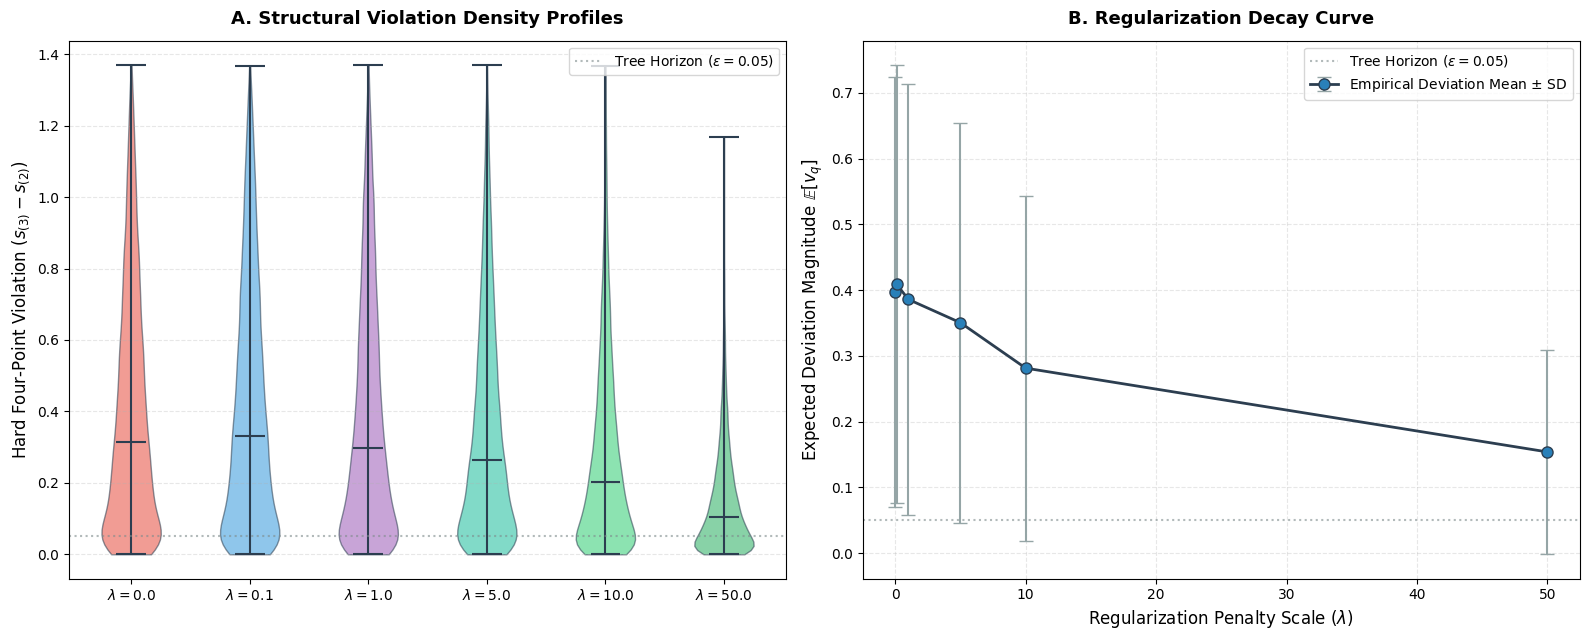

In [41]:
import sys
sys.path.append(".")  # Path fix for local 'src' imports

import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

from src.model import PhylogeneticPrior

# --- Global Configurations ---
N = 10        
K = 2         
B = 100       

SIGMA_U = 1.0
TAU = 0.1
LAMBDA_GRID = [0.0, 0.1, 1.0,5.0,  10.0, 50.0]

# Instantiate your project model globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    experiment_reports = {}

    print("Running MCMC Chains Sequentially to Bypass OS Traps...")

    for lmbda in LAMBDA_GRID:
        print(f"\nRunning Lambda = {lmbda}...")
        
        # Lists to store the trace data from our separate chains
        chain_samples = []
        chain_diagnostics = []
        
        # Run 2 chains one after the other completely inside the main process thread
        for chain_id in range(2):
            print(f"  └── Sampling Chain {chain_id + 1}/2...")
            pyro.clear_param_store()
            
            # Set a unique seed per chain so they sample from different starting points
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            # Clean default NUTS initialization running a single chain safely
            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=100, 
                warmup_steps=50, 
                num_chains=1  # Avoids triggering any background process engines
            )
            mcmc.run()
            
            # Extract current chain data
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # --- Merge Chain Data for ArviZ ---
        # Combine the unconstrained variables 'u' across a new chain axis
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0) # Shape: (chains, samples, N, K)
        posterior_dict = {"u": combined_u}
        
        # Re-materialize the distance matrices 'D' for our violin plot using the pooled trace
        pooled_samples = {"u": combined_u.view(-1, N, K)} # Flatten chain axis for Predictive
        def target_model_pooled():
            return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)
            
        predictive = infer.Predictive(target_model_pooled, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Calculate total combined divergences across both chains
        total_divergences = 0
        for diag in chain_diagnostics:
            total_divergences += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Convert the multi-chain dictionary data structure directly into ArviZ
        az_data = az.from_dict(posterior=posterior_dict)
        summary_stats = az.summary(az_data)
        
        mean_ess = summary_stats["ess_bulk"].mean()
        max_rhat = summary_stats["r_hat"].max()
        
        experiment_reports[lmbda] = {
            "mean_ess": mean_ess,
            "max_rhat": max_rhat,
            "divergences": total_divergences
        }
        
        
        print(f"  └── Mean Bulk ESS : {mean_ess:.2f}")
        print(f"  └── Max R-hat     : {max_rhat:.4f}")
        print(f"  └── Divergences   : {total_divergences}")

    # --- Focused Summary Report ---
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda, metrics in experiment_reports.items():
        print(f"{lmbda:<10} | {metrics['mean_ess']:<15.1f} | {metrics['max_rhat']:<12.4f} | {metrics['divergences']:<10}")
    print("="*55)

    # --- Advanced Visualization: Violin Grid + Regularization Decay Line Plot ---
    def extract_violations_only(D_batch, sampled_quartets):
        """Directly extracts hard four-point violations from a batch of samples."""
        a, b, c, d = sampled_quartets[:, 0], sampled_quartets[:, 1], sampled_quartets[:, 2], sampled_quartets[:, 3]
        
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        s_stacked = torch.stack([s1, s2, s3], dim=-1)
        s_sorted, _ = torch.sort(s_stacked, dim=-1)
        
        v_q = s_sorted[..., 2] - s_sorted[..., 1]
        return v_q.flatten().numpy()

    # 1. Compile the violation matrices and compute statistical aggregates
    all_violations = []
    violin_labels = []
    line_means = []
    line_stds = []

    for lmbda in LAMBDA_GRID:
        violations = extract_violations_only(saved_samples[lmbda], model_instance.fixed_indices)
        all_violations.append(violations)
        violin_labels.append(f"$\lambda = {lmbda}$")
        
        # Calculate aggregates for the decay line chart
        line_means.append(np.mean(violations))
        line_stds.append(np.std(violations))

    # Convert to arrays for clean indexing
    line_means = np.array(line_means)
    line_stds = np.array(line_stds)

    # 2. Setup a professional 1x2 dual-panel figure layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # ==========================================
    # PANEL 1: The Multi-Lambda Violin Grid
    # ==========================================
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True, showextrema=True)
    
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#2ECC71', '#27AE60']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.55)
        body.set_edgecolor('#2C3E50')

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels(violin_labels, fontsize=10)
    ax1.set_ylabel('Hard Four-Point Violation ($s_{(3)} - s_{(2)}$)', fontsize=12)
    ax1.set_title('A. Structural Violation Density Profiles', fontsize=13, fontweight='bold', pad=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.axhline(y=0.05, color='#7F8C8D', linestyle=':', alpha=0.6, label='Tree Horizon ($\epsilon = 0.05$)')
    ax1.legend(loc='upper right')

    # ==========================================
    # PANEL 2: The Regularization Decay Line Plot
    # ==========================================
    ax2.errorbar(
        LAMBDA_GRID, line_means, yerr=line_stds, 
        fmt='-o', color='#2C3E50', ecolor='#95A5A6',
        linewidth=2, elinewidth=1.5, capsize=5, markersize=8, 
        markerfacecolor='#2980B9', markeredgecolor='#2C3E50',
        label='Empirical Deviation Mean $\pm$ SD'
    )

    ax2.axhline(y=0.05, color='#7F8C8D', linestyle=':', alpha=0.6, label='Tree Horizon ($\epsilon = 0.05$)')

    ax2.set_xlabel('Regularization Penalty Scale ($\lambda$)', fontsize=12)
    ax2.set_ylabel('Expected Deviation Magnitude $\mathbb{E}[v_q]$', fontsize=12)
    ax2.set_title('B. Regularization Decay Curve', fontsize=13, fontweight='bold', pad=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.legend(loc='upper right')

    # 3. Compile and Render directly without writing local disk files
    plt.tight_layout()
    plt.show()